## In-Class Guided Exercise:

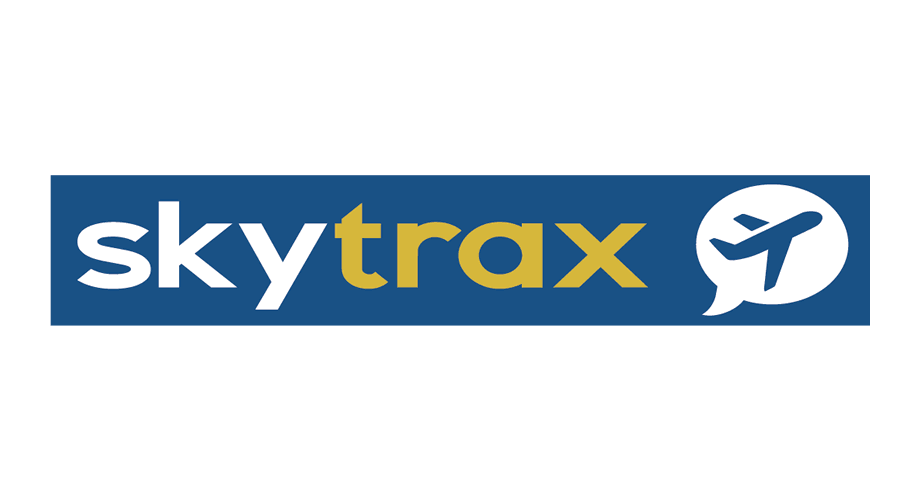

In [1]:
import requests
import httpx  # if you want to use httpx instead of requests

import pandas as pd
from bs4 import BeautifulSoup
from time import sleep


### Steps on web scraping using BeautifulSoup:
#### 1. Use `requests` to access the url of the web page you want to scrape

In [2]:
url="https://www.airlinequality.com/airline-reviews/qatar-airways/page/1/?sortby=post_date%3ADesc&pagesize=100"
# Your code here

In [3]:
# Your code here
html_page = requests.get(url)
html_page.status_code
# 200 mean OK 

200

In [222]:
# html_page.text[:2000] # First 2000 characters of the HTML

#### 2. Now that we have the web page, we can parse it with `BeautifulSoup`:

In [4]:
# Your code here
soup = BeautifulSoup(html_page.text,'html.parser')

- Get the title of the page using the tag 'title':

In [5]:
# soup.title
page_title = soup.title.string
page_title

'Qatar Airways Customer Reviews - SKYTRAX'

#### 3. Get all the items in that page
- Use `inspect` on the web page to know how to collect the items 
- Create a variable that contains all the items in that web page


In [6]:
# Find all the elements in the page

# complete the code
skytrax= soup.find_all('article', itemprop="review")

len(skytrax)

100

In [7]:
# Check one of the items collected
skytrax[0]

<article class="comp comp_media-review-rated list-item media position-content review-949910" itemprop="review" itemscope="" itemtype="http://schema.org/Review">
<meta content="2026-07-09" itemprop="datePublished"/>
<div class="rating-10" itemprop="reviewRating" itemscope="" itemtype="http://schema.org/Rating">
<span itemprop="ratingValue">5</span>/<span itemprop="bestRating">10</span>
</div>
<div class="body" id="anchor949910">
<h2 class="text_header">“ they declined a small goodwill gesture”</h2>
<h3 class="text_sub_header userStatusWrapper">
<span itemprop="author" itemscope="" itemtype="http://schema.org/Person">
<span itemprop="name">Paul Nicoll</span></span> (United Kingdom) <time datetime="2026-07-09" itemprop="datePublished">9th July 2026</time></h3>
<div class="tc_mobile">
<div class="text_content" itemprop="reviewBody">✅ <strong><a href="https://www.airlinequality.com/verified-reviews/"><em>Trip Verified</em></a></strong> |   There were several issues, including the onboard se

#### 4. Using one item, try to collect the information that you want to scrape

##### 4.1 *Review Title (remove the internal double quotation)*

In [8]:
skytrax[0].find(class_="text_header").text.replace('“',' ').replace('”',' ')

'  they declined a small goodwill gesture '

##### 4.2 *Reviewer Name*

In [9]:
skytrax[0].find(itemprop="name").text

'Paul Nicoll'

##### 4.3 *Reviewer Location* (Challenge)

In [10]:
# Safe method: Returns None instead of crashing if 'aria-label' is missing
skytrax[0].find('h3').text.strip().split('(')[1].split(')')[0]

'United Kingdom'

##### 4.4 *Review Time (in the format yyyy-mm-dd)* 

In [11]:
skytrax[0].find('time')['datetime']

'2026-07-09'

##### 4.5 *Verified?*

In [12]:
skytrax[0].find('a').text

'Trip Verified'

##### 4.6 *Get the Review*

In [13]:
# review
skytrax[0].find(class_="text_content").text.split('|')[1]

'   There were several issues, including the onboard service, condition of the lavatory, problems with the moving map and a disappointing breakfas. I contacted Customer Care, and while they responded promptly, I was disappointed that they declined even a small goodwill gesture.'

##### 4.7 *Get the Aircraft model*

In [14]:
#Aircraft
skytrax[3].find('td', class_="review-rating-header aircraft").find_next_sibling('td').text

'A330-200'

##### 4.8 *Get Type of Traveller*

In [15]:
#Type Of Traveller
skytrax[0].find('td',class_ = 'review-rating-header type_of_traveller').find_next_sibling('td').text

'Solo Leisure'

##### 4.9 *Get the Seat Type*

In [16]:
skytrax[0].find('td', class_='review-rating-header cabin_flown').find_next_sibling('td').text

'Business Class'

##### 4.10 *Get the Route*

In [17]:
skytrax[0].find('td', class_="review-rating-header route").find_next_sibling('td').text

'Sydney to Doha'

##### 4.11 *Get the Date Flown*

In [18]:
skytrax[0].find('td', class_="review-rating-header date_flown").find_next_sibling('td').text

'July 2026'

##### 4.12 *Get the overall rating(the orange circle to the left)*

In [19]:
skytrax[0].find('span', itemprop='ratingValue').text

'5'

#### Get the Ratings/Stars

> We are facing a new issue here. \
> There is no direct rating stars from the output. \
> The star that is filled will be 'star fill' while the unfilled star is 'star'. \
> We need to create a function to calculate exactly number of stars for each rating. \
> create a function `get_stars` to calculate how many stars.
> it would take a complete `td class element` same as the following and returns number of `star fill`:

```html
 <td class="review-rating-stars stars">
     <span class="star fill">1</span>
     <span class="star fill">2</span>
     <span class="star fill">3</span>
     <span class="star">4</span>
     <span class="star">5</span></td> 
```

In [20]:
# Creating a function to calculate the number of stars
def get_stars(x):
    # complete the code for the function
    return len(x.find_all(class_="star fill"))

##### 4.13 *Get Seat Comfort rating*

> Notice that the tag and the class name for all the following ratings are the same which is 'review-rating-stars stars'. \
> We are able to do it for the first star rating but not for the rest. \
> To solve this, we have to search for the class name that contains the star rating title then use 'find_next_siblings' to seach for the next 'td' class.


In [26]:
get_stars(skytrax[0].find(class_="review-rating-header seat_comfort").find_next_sibling('td'))

5

##### 4.14 *Get Cabin Staff Service rating*

In [27]:
get_stars(skytrax[0].find(class_="review-rating-header cabin_staff_service").find_next_sibling('td'))

3

##### 4.15 *Get Food & Beverages rating*

In [28]:
get_stars(skytrax[0].find(class_="review-rating-header food_and_beverages").find_next_sibling('td'))

3

##### 4.16 *Get Inflight Entertainment rating*

In [29]:
get_stars(skytrax[0].find(class_="review-rating-header inflight_entertainment").find_next_sibling('td'))

3

##### 4.17 *Get Ground Service rating*

In [30]:
get_stars(skytrax[0].find(class_="review-rating-header ground_service").find_next_sibling('td'))

5

##### 4.18 *Get Value For Money rating*

In [31]:
get_stars(skytrax[0].find(class_="review-rating-header value_for_money").find_next_sibling('td'))

3

##### 4.19 *Get Recommended*

In [34]:
skytrax[0].find(class_="review-rating-header recommended").find_next_sibling('td').text

'no'

#### 5. Collect all the information of all the items using `loops`
- Now, once we know how to get in information we want from one item, we can now collect all the information from all the items using `for loop`
- **First of all**, we need to create a list for each info we want to collect and append the scraped info to those lists

In [36]:
# define the empty lists

title = []
name = []
location = []
time = []
verfied = []
review = []
aircraft_model = []
type_of_traveller = []
seat_type = []
route = []
date_flown = []
rating = []
Seat_Comfort = []
cabin_staff_service_rating = []
food_and_beverage_rating = []
inflight_entertainment_rating = []
ground_service_rating = []
value_for_money_rating = []
recommended = []

# your code here

for i in skytrax:
    try:
        title.append(i.find("h2", class_ = "text_header").text.strip('"" '))
    except:
        title.append(None)

    try:
        name.append(i.find("span", itemprop="name").text)
    except:
        name.append(None)

    try:
        location.append(i.find("h3").text.strip().split("(")[1].split(")")[0])
    except:
        location.append(None)

    try:
        time.append(i.find("time")["datetime"])
    except:
        time.append(None)

    try:
        verfied.append(i.find("em").text)
    except:
        verfied.append(None)

    try:
        review.append(i.find("div", class_ = "text_content").text.strip().split("|   ")[1])
    except:
        review.append(None)

    try:
        aircraft_model.append(i.find("td", class_ = "review-rating-header aircraft").find_next_sibling("td").text)
    except:
        aircraft_model.append(None)

    try:
        type_of_traveller.append(i.find("td", class_ = "review-rating-header type_of_traveller").find_next_sibling("td").text)
    except:
        type_of_traveller.append(None)

    try:
        seat_type.append(i.find("td", class_ = "review-rating-header cabin_flown").find_next_sibling("td").text)
    except:
        seat_type.append(None)

    try:
        route.append(i.find("td", class_ = "review-rating-header route").find_next_sibling("td").text)
    except:
        route.append(None)

    try:
        date_flown.append(i.find("td", class_ = "review-rating-header date_flown").find_next_sibling("td").text)
    except:
        date_flown.append(None)

    try:
        rating.append(i.find("span", itemprop = "ratingValue").text)
    except:
        rating.append(None)

    try:
        Seat_Comfort.append(i.find(class_="review-rating-header seat_comfort").find_next_sibling('td'))
    except:
        Seat_Comfort.append(None)
        
    try:
        cabin_staff_service_rating.append(get_stars(i.find(class_ = "review-rating-header cabin_staff_service").find_next_sibling("td")))
    except:
        cabin_staff_service_rating.append(None)

    try:
        food_and_beverage_rating.append(get_stars(i.find(class_ = "review-rating-header food_and_beverages").find_next_sibling("td")))
    except:
        food_and_beverage_rating.append(None)

    try:
        inflight_entertainment_rating.append(get_stars(i.find(class_ = "review-rating-header inflight_entertainment").find_next_sibling("td")))
    except:
        inflight_entertainment_rating.append(None)

    try:
        ground_service_rating.append(get_stars(i.find(class_ = "review-rating-header ground_service").find_next_sibling("td")))
    except:
        ground_service_rating.append(None)

    try:
        value_for_money_rating.append(get_stars(i.find(class_ = "review-rating-header value_for_money").find_next_sibling("td")))
    except:
        value_for_money_rating.append(None)

    try:
        recommended.append(i.find("td", class_ = "review-value rating-no").text)
    except:
        recommended.append(None)

#### 7. Create a DataFrame to save all the scraped info. into a table.


In [38]:
skytrax_df=  pd.DataFrame(
    {
        'title': title,
        'name': name,
        'location': location,
        'time':time,
        'verfied':verfied,
        'review': review,
        'aircraft_model': aircraft_model,
        'type_of_traveller': type_of_traveller,
        'seat_type': seat_type,
        'route': route,
        'date_flown': date_flown,
        'rating': rating,
        'Seat_Comfort': Seat_Comfort,
        'cabin_staff_service_rating': cabin_staff_service_rating,
        'food_and_beverage_rating': food_and_beverage_rating,
        'inflight_entertainment_rating': inflight_entertainment_rating,
        'ground_service_rating': ground_service_rating,
        'value_for_money_rating': value_for_money_rating,
        'recommended': recommended
    }
) 


In [39]:
skytrax_df.head()

,title,name,location,time,verfied,review,aircraft_model,type_of_traveller,seat_type,route,date_flown,rating,Seat_Comfort,cabin_staff_service_rating,food_and_beverage_rating,inflight_entertainment_rating,ground_service_rating,value_for_money_rating,recommended
0,“ they declined a small goodwill gesture”,Paul Nicoll,United Kingdom,2026-07-09,Trip Verified,"There were several issues, including the onboa...",NaN,Solo Leisure,Business Class,Sydney to Doha,July 2026,5,"[[1], [2], [3], [4], [5]]",3.0,3.0,3.0,5.0,3,no
1,showed incredible leadership,Maher AlShaaban,Qatar,2026-06-24,Trip Verified,NaN,NaN,Family Leisure,Economy Class,Doha to Jakarta,June 2026,10,"[[1], [2], [3], [4], [5]]",5.0,4.0,1.0,5.0,5,NaN
2,just had to just sleep,Alwaleed Althani,Qatar,2026-06-06,Trip Verified,Came in on a connecting flight on Cathay Pacif...,A350-1000,Couple Leisure,Business Class,Hong Kong to Doha,May 2026,9,"[[1], [2], [3], [4], [5]]",4.0,NaN,NaN,3.0,4,NaN
3,sandwich no choice,Alwaleed Althani,Qatar,2026-06-06,Trip Verified,A330 comfortable but very much underwhelming. ...,A330-200,Couple Leisure,Business Class,CAN to HKG,May 2026,6,"[[1], [2], [3], [4], [5]]",3.0,1.0,1.0,3.0,3,NaN
4,cabin crew was professional and friendly,L Casine,France,2026-05-29,Trip Verified,I recently flew with Qatar Airways on a Boeing...,Boeing 777-300ER,Business,Economy Class,Guangzhou to Doha,May 2026,6,"[[1], [2], [3], [4], [5]]",5.0,5.0,5.0,2.0,2,no


#### 8. Save your dataframe to a `CSV` file
- Save the output to a csv file (excluding the index)

In [40]:
# Save the output to a csv file (excluding the index)

# your code here
skytrax_df.to_csv("skytrax.csv",index=False)